# Indian Weather & Rainfall Analysis

# 03 - Exploratory Data Analysis (EDA)

## ---

## Objective

### The objective of this notebook is to explore the cleaned weather dataset and uncover meaningful insights through data visualization and statistical analysis.

### The analysis focuses on:

#### - Understanding temperature distribution
#### - Analyzing rainfall patterns
#### - Comparing weather across Indian states
#### - Studying seasonal weather changes
#### - Identifying yearly trends
#### - Exploring relationships among weather variables

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/cleaned_weather_data.csv")
df["date_of_record"] = pd.to_datetime(df["date_of_record"])
df.head()

,date_of_record,month,season,station_name,state,district,avg_temp,min_temp,max_temp,wind_speed,air_pressure,elevation,latitude,longitude,rainfall,year,month_no,state_name
0,2021-01-02,January,Winter,Gulmarg,JK,Baramulla,-2.2,-6.6,-0.8,2.2,1020.0,2652,34.05,74.4,0.1,2021,1,Jammu and Kashmir
1,2021-01-03,January,Winter,Gulmarg,JK,Baramulla,-3.6,-4.6,-1.8,3.7,1019.5,2652,34.05,74.4,4.4,2021,1,Jammu and Kashmir
2,2021-01-04,January,Winter,Gulmarg,JK,Baramulla,-3.0,-4.5,-1.1,2.1,1022.0,2652,34.05,74.4,2.3,2021,1,Jammu and Kashmir
3,2021-01-05,January,Winter,Gulmarg,JK,Baramulla,-3.3,-5.1,-1.2,2.8,1015.6,2652,34.05,74.4,35.0,2021,1,Jammu and Kashmir
4,2021-01-06,January,Winter,Gulmarg,JK,Baramulla,-3.9,-8.3,-1.0,3.4,1015.3,2652,34.05,74.4,25.5,2021,1,Jammu and Kashmir


## Dataset Overview

In [3]:
df.shape

(970338, 18)

In [4]:
df.columns

Index(['date_of_record', 'month', 'season', 'station_name', 'state',
       'district', 'avg_temp', 'min_temp', 'max_temp', 'wind_speed',
       'air_pressure', 'elevation', 'latitude', 'longitude', 'rainfall',
       'year', 'month_no', 'state_name'],
      dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 970338 entries, 0 to 970337
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   date_of_record  970338 non-null  datetime64[us]
 1   month           970338 non-null  str           
 2   season          970338 non-null  str           
 3   station_name    970338 non-null  str           
 4   state           970338 non-null  str           
 5   district        970338 non-null  str           
 6   avg_temp        970338 non-null  float64       
 7   min_temp        970338 non-null  float64       
 8   max_temp        970338 non-null  float64       
 9   wind_speed      970338 non-null  float64       
 10  air_pressure    970338 non-null  float64       
 11  elevation       970338 non-null  int64         
 12  latitude        970338 non-null  float64       
 13  longitude       970338 non-null  float64       
 14  rainfall        970338 non-null  float64       

In [6]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
date_of_record,970338,2021-03-27 08:52:49.241232,2015-01-01 00:00:00,2019-03-07 00:00:00,2021-11-09 00:00:00,2023-06-24 00:00:00,2025-02-10 00:00:00,NaN
avg_temp,970338.0,25.661695,-10.4,23.1,26.7,29.1,43.4,5.43812
min_temp,970338.0,20.661271,-18.5,17.1,22.4,25.0,36.6,5.983606
max_temp,970338.0,31.215056,-5.6,28.6,31.5,34.4,52.4,5.34431
wind_speed,970338.0,9.216011,0.0,6.2,8.2,11.3,66.6,4.526945
air_pressure,970338.0,1009.403895,922.6,1007.6,1009.3,1012.0,1036.5,4.44471
elevation,970338.0,298.180929,0.0,16.0,139.0,436.0,2652.0,415.266419
latitude,970338.0,20.793664,7.9833,15.85,21.6167,25.5667,34.0833,6.328276
longitude,970338.0,79.426829,68.85,75.4,78.0667,82.7167,95.3833,5.852514
rainfall,970338.0,4.039663,0.0,0.0,0.0,2.2,485.9,12.57358


### Data Quality Check

In [7]:
df.isnull().sum()

date_of_record    0
month             0
season            0
station_name      0
state             0
district          0
avg_temp          0
min_temp          0
max_temp          0
wind_speed        0
air_pressure      0
elevation         0
latitude          0
longitude         0
rainfall          0
year              0
month_no          0
state_name        0
dtype: int64

In [8]:
df["state_name"].nunique()

32

In [9]:
df["season"].value_counts()

season
Winter          333244
Monsoon         241027
Summer          234371
Post-monsoon    161696
Name: count, dtype: int64

In [10]:
df["date_of_record"].min(), df["date_of_record"].max()

(Timestamp('2015-01-01 00:00:00'), Timestamp('2025-02-10 00:00:00'))

In [11]:
df["district"].nunique()

314

In [12]:
df["station_name"].nunique()

406

# Univariate Analysis

### Univariate Analysis examines one variable at a time to understand its distribution, spread, central tendency, and presence of outliers.

### In this section, we analyze:

- Rainfall
- Average Temperature
- Wind Speed
- Air Pressure

### For each variable, we will use:

- Histogram + KDE Curve
- Box Plot
- Observations

## Distribution of Rainfall

This section examines how rainfall values are distributed across all weather observations.

The histogram shows the frequency distribution, while the KDE (Kernel Density Estimation) curve represents the probability density.

The boxplot helps identify the spread of rainfall values and detects potential outliers.

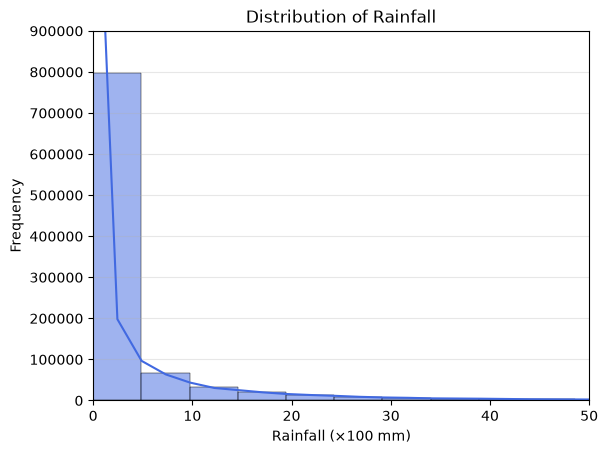

In [13]:
sns.histplot(df, x=df["rainfall"], bins=100, kde=True, color="royalblue")

plt.title("Distribution of Rainfall")
plt.xlabel("Rainfall (×100 mm)")
plt.ylabel("Frequency")
plt.xlim(0,50)
plt.ylim(0, 900000)
plt.savefig("dist_rain.png")

plt.grid(axis="y", alpha=0.3)
plt.show()

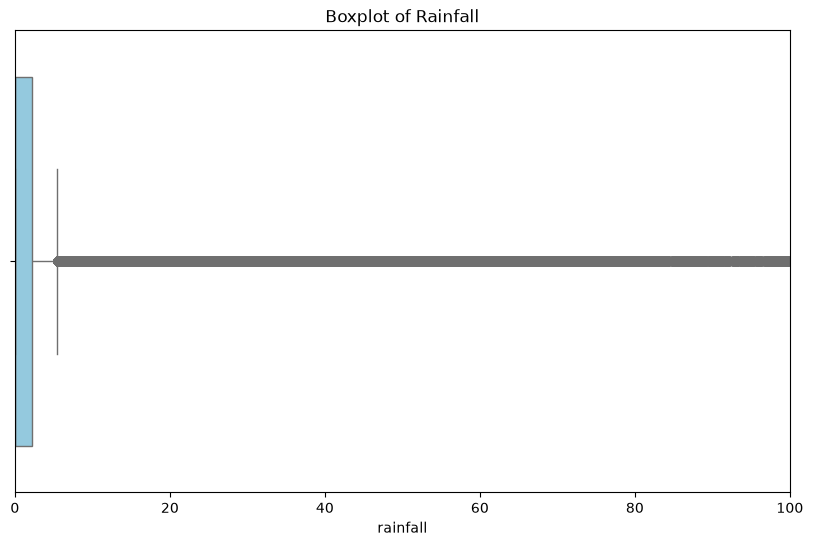

In [14]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x=df["rainfall"],
    color="skyblue"
)

plt.xlim(0,100)

plt.title("Boxplot of Rainfall")

plt.show()

### Observation

- Rainfall values are positively (right) skewed.
- Most observations record relatively low rainfall.
- A few observations have extremely high rainfall.
- The boxplot confirms the presence of several high-value outliers.
- These outliers correspond to heavy rainfall events and represent genuine weather conditions rather than data errors.

## Distribution of Average Temperature

This analysis explores how average temperature values are distributed across the dataset.

The histogram illustrates the frequency of temperatures, while the boxplot highlights variability and possible outliers.

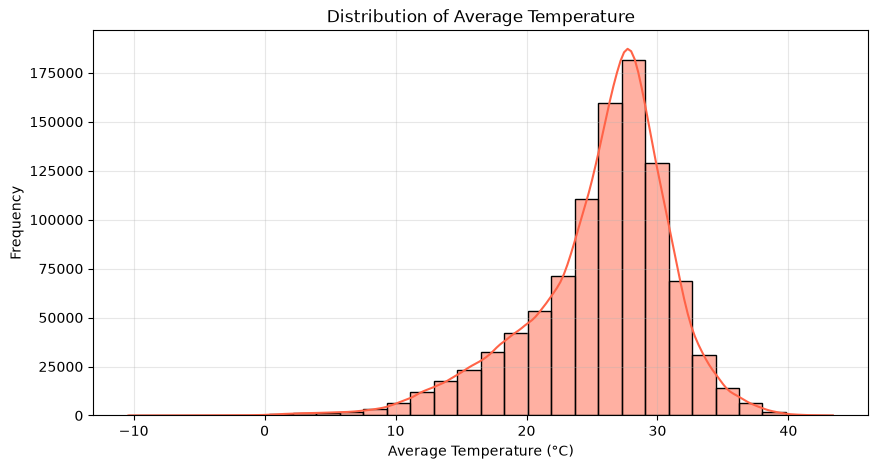

In [15]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x="avg_temp",
    bins=30,
    kde=True,
    color="tomato"
)

plt.title("Distribution of Average Temperature")

plt.xlabel("Average Temperature (°C)")
plt.ylabel("Frequency")

plt.grid(alpha=0.3)

plt.show()

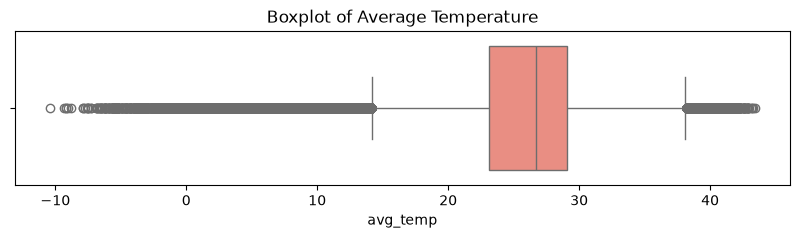

In [16]:
plt.figure(figsize=(10,2))

sns.boxplot(
    x=df["avg_temp"],
    color="salmon"
)

plt.title("Boxplot of Average Temperature")

plt.show()

### Observation

- Average temperature is approximately normally distributed.
- Most observations lie between 20°C and 32°C.
- Very few observations fall below 10°C or above 38°C.
- The boxplot indicates only a small number of outliers.
- Overall, temperature values are well distributed compared to rainfall.

## Distribution of Wind Speed

This section analyzes the distribution of wind speed across different weather observations.

The histogram shows how frequently different wind speed values occur, while the boxplot highlights the spread of the data and any outliers.

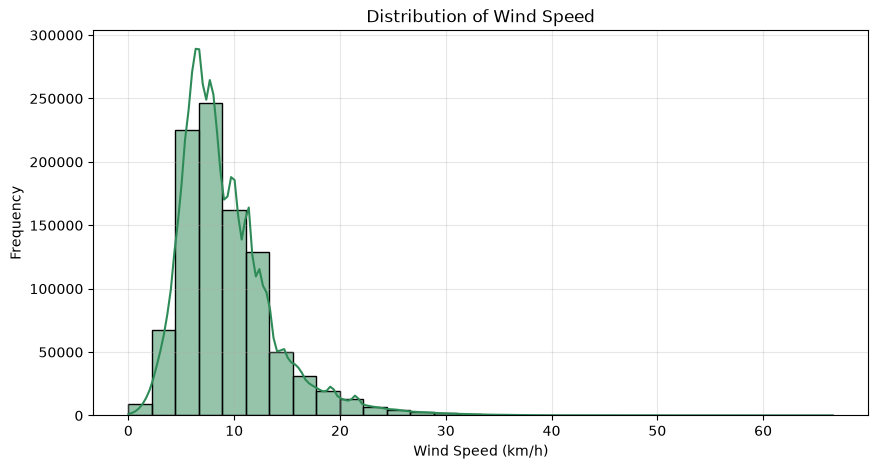

In [17]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x="wind_speed",
    bins=30,
    kde=True,
    color="seagreen"
)

plt.title("Distribution of Wind Speed")
plt.xlabel("Wind Speed (km/h)")
plt.ylabel("Frequency")

plt.grid(alpha=0.3)

plt.show()

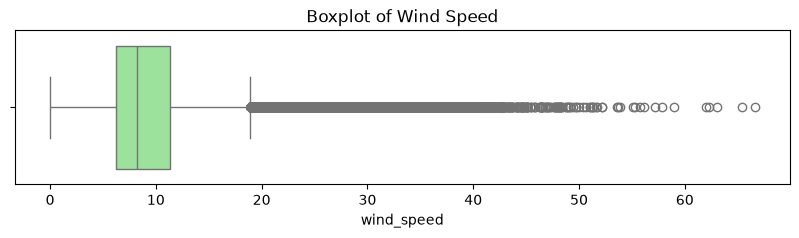

In [18]:
plt.figure(figsize=(10,2))

sns.boxplot(
    x=df["wind_speed"],
    color="lightgreen"
)

plt.title("Boxplot of Wind Speed")

plt.show()

### Observation

- Wind speed values are concentrated within a moderate range.
- The distribution is slightly right-skewed.
- A few observations have unusually high wind speeds.
- The boxplot confirms the presence of some outliers.

## Distribution of Air Pressure

Air pressure is an important atmospheric variable that influences weather conditions.

The following plots illustrate its frequency distribution and identify potential outliers.

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x="air_pressure",
    bins=30,
    kde=True,
    color="orange"
)

plt.title("Distribution of Air Pressure")

plt.xlabel("Air Pressure (hPa)")
plt.ylabel("Frequency")

plt.grid(alpha=0.3)

plt.show()

In [ ]:
plt.figure(figsize=(10,2))

sns.boxplot(
    x=df["air_pressure"],
    color="gold"
)

plt.title("Boxplot of Air Pressure")

plt.show()

### Observation

- Air pressure values are approximately normally distributed.
- Most observations lie within a narrow pressure range.
- Only a few extreme observations appear as outliers.
- Overall, air pressure remains relatively stable across the dataset.

# Summary of Univariate Analysis

The univariate analysis reveals the following insights:

- Rainfall is highly right-skewed with several extreme rainfall events.
- Average temperature follows an approximately normal distribution.
- Wind speed exhibits moderate variability with a few high-value outliers.
- Air pressure remains relatively stable and shows only minor variation.

These observations provide a better understanding of the individual characteristics of each weather variable before exploring relationships between variables.

## Correlation Analysis

In [ ]:
df_corr = df[
    [
        "avg_temp",
        "min_temp",
        "max_temp",
        "wind_speed",
        "air_pressure",
        "elevation",
        "latitude",
        "longitude",
        "rainfall",
    ]
].corr()
df_corr

In [ ]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df_corr,
    annot=True,
    linewidth=1,
    linecolor="black",
    cmap="rocket",
    vmin=-1,
    vmax=1,
)

plt.title("Correlation Heatmap")
plt.show()

### Observation

- Average, minimum, and maximum temperatures are strongly positively correlated.
- Air pressure has a moderate negative correlation with temperature.
- Rainfall has a weak relationship with temperature variables.
- Wind speed shows only a slight positive correlation with rainfall.
- Overall, temperature variables exhibit the strongest relationships in the dataset.